y [[1.         1.0022372  1.00405013 1.00565302 1.00732295 1.00899044
  1.01062101 1.01223758 1.01384248 1.0154221  1.0170044  1.01858843
  1.02014317 1.02166537 1.02316743 1.02467005 1.02616721 1.02763847
  1.02909367 1.03054331 1.03197943 1.03339568 1.0347913  1.03617881
  1.03755962 1.03892294 1.04027107 1.0416071  1.0429276  1.04423593
  1.04553211 1.04681404 1.04807943 1.04936621 1.05064485 1.05199107
  1.05332043 1.05471483 1.05608915 1.05753933 1.05897712 1.06048432
  1.06196847 1.06352479 1.06505672 1.06666708 1.06825747 1.06992093
  1.07155449 1.07326081 1.07493465 1.07668642 1.07840874 1.08020402
  1.08196112 1.08378929 1.08557893 1.08744247 1.08925977 1.09114759
  1.09299072 1.09489786 1.09675138 1.09866717 1.10052796 1.10244913
  1.10430869 1.10622307 1.10807391 1.10996923 1.11179242 1.11365859
  1.11545025 1.11727744 1.11902605 1.12080022 1.12248969 1.12418244
  1.12579046 1.12732338 1.12877604 1.1301506  1.13145186 1.13268264
  1.13384596 1.13494365 1.13597951 1.1369562  

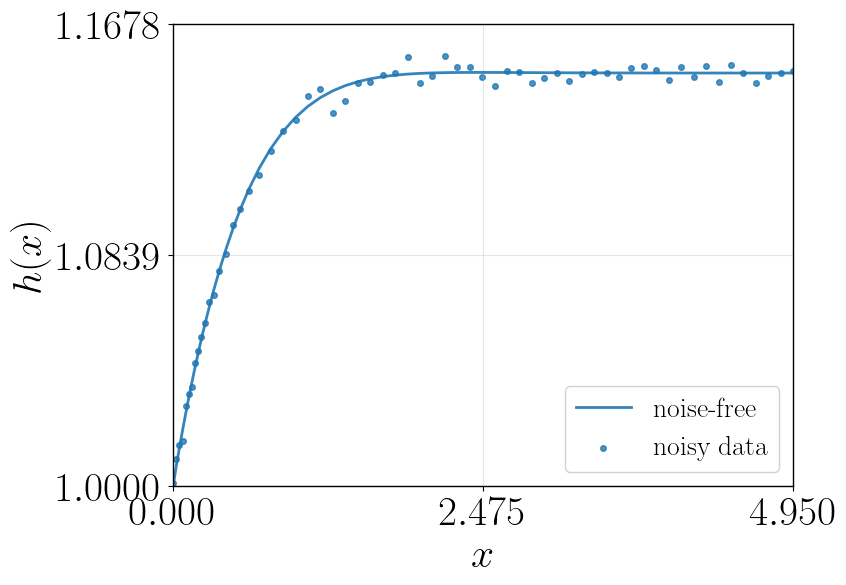

curve4_y GPR on (lambda, beta), 72 curves: 0.22**2 * RBF(length_scale=[0.408, 0.588])
MLE fit: lambda = 3.063, beta = 0.463; sigma_MLE = RMS(delta) = 0.001091, max|delta(x)| = 0.002216
sigma_bias prior: exponential with mean sigma_MLE = 0.001091


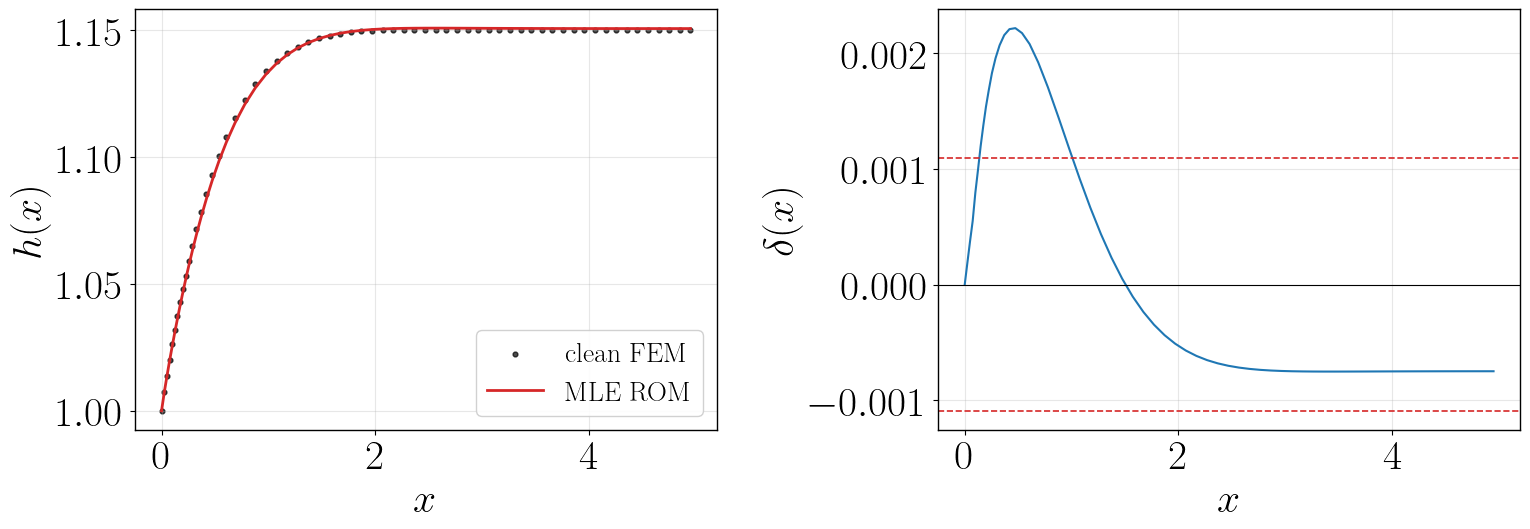

In [ ]:
import sys
import os
from pathlib import Path

CURRENT_DIR = os.getcwd()
FAXEN_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, '..'))
sys.path.append(FAXEN_ROOT)
from packages import ROMCurve4BayesianInference

model = ROMCurve4BayesianInference(
    swell_root=Path(FAXEN_ROOT),
    model="oldroyd",
    parametrize = False,   
    train_data_rels=["datas/oldroyd-rom1/train-0.05"],    
    filenames_train=("curve4_y_all.txt",  "parameters.txt"),  
    lambda_bounds = (0.2, 5.0),
    beta_bounds = (0.08, 0.9),
    sigma_noise_percent=2.0,
    thin=4,
    sigma_bias=True,
    constrained_model_error=True, 
    l_bias = 0.5, U_avg = 0.05, seed = 1)

model.load_data(filename="datas/oldroyd-rom1/infer-0.05/giesekus_lam_5_beta_0p5_alpha_0p1/curve4_y.txt")
model.plot_data()
model.build_rom()
model.plot_prior()
model.run_mcmc(nwalkers=20, nsteps=20000, burn_fraction=0.5)
model.compute_N1()
model.plot_corner_all()
model.plot_trace_all()
model.plot_posterior_predictive()